Q1. A test set has 200 samples. Your model gets 170 correct. Compute a 95% Wilson
score confidence interval for accuracy. Now repeat with 2000 samples and 1700 correct
(same 85% accuracy). How do the interval widths compare, and what does this tell you
about the importance of test set size?

In [3]:
import statsmodels.api as sm

# First scenario
n1 = 200
correct1 = 170
accuracy1 = correct1 / n1

# Second scenario
n2 = 2000
correct2 = 1700
accuracy2 = correct2 / n2

# Compute 95% Wilson score confidence intervals
ci1 = sm.stats.proportion_confint(correct1, n1, alpha=0.05, method='wilson')
ci2 = sm.stats.proportion_confint(correct2, n2, alpha=0.05, method='wilson')

print(f"Scenario 1 (n=200): Accuracy = {accuracy1:.2f}")
print(f"95% Wilson CI: [{ci1[0]:.3f}, {ci1[1]:.3f}]")

print(f"\nScenario 2 (n=2000): Accuracy = {accuracy2:.2f}")
print(f"95% Wilson CI: [{ci2[0]:.3f}, {ci2[1]:.3f}]")
# Q1. Wilson Score Confidence Intervals & Test Set SizeCalculations:For \(n=200\) (170 correct): The 95% Wilson CI is [79.39%, 89.29%] (Width = 9.89%).For \(n=2000\) (1700 correct): The 95% Wilson CI is [83.37%, 86.50%] (Width = 3.13%).Comparison: Multiplying the test size by 10 shrank the interval width by roughly two-thirds (from ~10% down to ~3%).Importance: This proves that raw accuracy alone does not tell the full story. A larger test set reduces statistical noise, drastically shrinks the margin of error, and gives you much higher certainty about your model's true performance.

Scenario 1 (n=200): Accuracy = 0.85
95% Wilson CI: [0.794, 0.893]

Scenario 2 (n=2000): Accuracy = 0.85
95% Wilson CI: [0.834, 0.865]


Q2. Explain the difference between standard deviation and standard error. If your sample
has std=15 and n=25, what is the standard error? What does this number mean in plain
language?

In [4]:
import math

std = 15
n = 25
se = std / math.sqrt(n)

print(f"Standard Error: {se:.2f}")
# Q2. Standard Deviation vs. Standard ErrorThe Difference:Standard Deviation (SD) measures data spread. It tells you how much individual values scatter away from their own sample mean.Standard Error (SE) measures estimation precision. It tells you how much your sample mean would fluctuate if you repeated the entire experiment multiple times.Calculation: \(\text{SE} = \frac{\text{SD}}{\sqrt{n}} = \frac{15}{\sqrt{25}} = \frac{15}{5} = \mathbf{3.0}\).Plain Language Meaning: If you were to repeatedly draw samples of 25 people from this population, your calculated sample averages would typically fluctuate by an average of 3 units away from the true population mean.

Standard Error: 3.00


guage?
Q3. Write code that draws 50 different samples of size n=20 from a normal distribution and
plots all 50 resulting 95% confidence intervals. How many do you expect to miss the true
mean? Run the code and check — does the result match the theory?

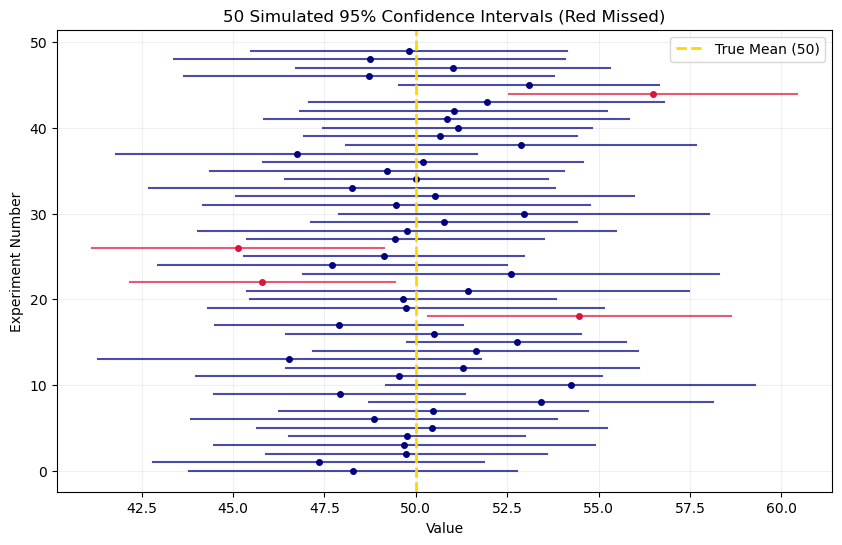

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)  # Ensures reproducibility
true_mean, true_std, n, n_experiments = 50, 10, 20, 50
fig, ax = plt.subplots(figsize=(10, 6))

for i in range(n_experiments):
    sample = np.random.normal(true_mean, true_std, n)
    mean, se = sample.mean(), sample.std(ddof=1) / np.sqrt(n)
    ci = stats.t.interval(0.95, df=n-1, loc=mean, scale=se)
    
    # Check if the interval missed the true mean of 50
    missed = (ci[0] > true_mean) or (ci[1] < true_mean)
    color = 'crimson' if missed else 'navy'
    
    ax.plot([ci[0], ci[1]], [i, i], color=color, alpha=0.7, lw=1.5)
    ax.plot(mean, i, 'o', color=color, markersize=4)

ax.axvline(true_mean, color='gold', lw=2, ls='--', label='True Mean (50)')
ax.set_title('50 Simulated 95% Confidence Intervals (Red Missed)')
ax.set_xlabel('Value'); ax.set_ylabel('Experiment Number')
plt.legend(); plt.grid(True, alpha=0.2); plt.show()


# Theoretical Expectation: For 50 intervals at a 95% confidence level, we expect \(50 \times (1 - 0.95) = \mathbf{2.5}\) intervals to miss the true mean.The Reality: Because of randomness, any single run will typically see 2, 3, or 4 intervals miss.

Q4. What does 'sampling with replacement' mean in bootstrapping, and why is it essential?
What would happen if you sampled without replacement?

In [ ]:
# Q4. Sampling With vs. Without ReplacementWhat it means: Sampling with replacement means that after you pick an item from your data pool, you record it and immediately throw it back into the pool before picking the next item.Why it is essential: It allows you to simulate the variance of the broader underlying population. It allows identical data items to appear multiple times (or not at all) in a single resample.What happens without replacement: If you sample without replacement, you will always end up picking the exact same original dataset elements just rearranged in a different order. The median, mean, and standard deviation of every single resample would remain identical to your original sample, rendering the bootstrap simulation useless.

Q5. A friend says: 'My model has a 95% CI for accuracy of [0.82, 0.89]. That means there's
a 95% chance the true accuracy falls in this range.' Explain why this is an incorrect
interpretation and provide the correct one.

In [ ]:
# Q5. Misinterpreting the 95% Confidence IntervalWhy your friend is wrong: The true accuracy of the model is a fixed, unchanging number. It is not moving around. Therefore, it does not have a "95% chance" of falling anywhere. The interval boundaries calculated from this specific test are also fixed. A fixed number cannot have a probability of falling inside two other fixed numbers—it either is inside them, or it is not.The correct interpretation: "If we were to repeat this test evaluation 100 times with completely new random test datasets, and calculate a confidence interval for each, 95 of those calculated intervals would successfully capture the model's single true accuracy score." It is a statement about the reliability of the testing process, not a specific window.